# Superstore Sales Intelligence Analysis
## End-to-End Data Analysis Project | Python · PostgreSQL · SQL · Tableau

This project analyzes 4 years of retail sales data from the Superstore dataset
to uncover business insights across product performance, customer segments,
geographic trends, and return patterns.

The analysis follows a complete data pipeline:
- **ETL** — raw Excel data normalized into a relational database
- **EDA** — exploratory analysis to answer core business questions
- **ML Model** — return prediction using Random Forest with SMOTE

**Tools:** Python · Pandas · Matplotlib · Seaborn · PostgreSQL · Scikit-learn · Tableau

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

The raw Superstore dataset is a single flat Excel file with 9,994 order records
across three sheets. Before any analysis, I normalized it into five relational
tables — products, customers, orders, order items, and geography — mirroring
how this data would be structured in a real production database.

This step also loads the Returns and People reference tables, which are used
later in the returns analysis and ML model.

In [9]:
from pathlib import Path

FILE_PATH = Path("data/raw/Sample - Superstore.xlsx")

df            = pd.read_excel(FILE_PATH, sheet_name='Orders',  engine='openpyxl')
returns_df    = pd.read_excel(FILE_PATH, sheet_name='Returns', engine='openpyxl')
people_df     = pd.read_excel(FILE_PATH, sheet_name='People',  engine='openpyxl')

products_table   = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']].drop_duplicates().reset_index(drop=True)
customers_table  = df[['Customer ID', 'Customer Name', 'Segment']].drop_duplicates().reset_index(drop=True)
orders_table     = df[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Postal Code']].drop_duplicates().reset_index(drop=True)
order_items_table = df[['Order ID', 'Product ID', 'Sales', 'Quantity', 'Discount', 'Profit']].drop_duplicates().reset_index(drop=True)

print("Data loaded successfully!")
print(f"Orders: {orders_table.shape} | Items: {order_items_table.shape}")

Data loaded successfully!
Orders: (5009, 6) | Items: (9993, 6)


## Exploratory Data Analysis

With the data structured and clean, the goal here is to answer three core
business questions before moving into predictive modeling:

1. Which product categories drive the most revenue — and are they equally profitable?
2. Is the business growing year over year?
3. Which customer segments and regions represent the biggest opportunities?

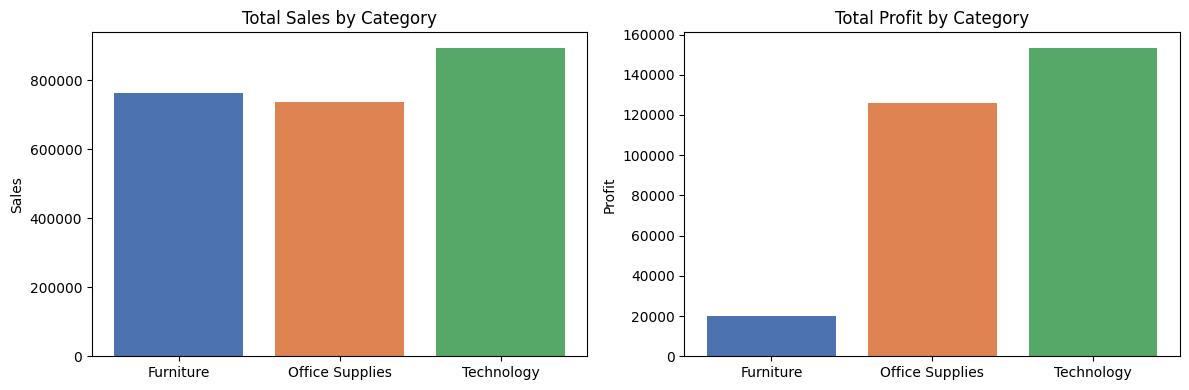

In [10]:
category = order_items_table.merge(products_table, on='Product ID')
cat_summary = category.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cat_summary['Category'], cat_summary['Sales'], color=['#4C72B0','#DD8452','#55A868'])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales')

axes[1].bar(cat_summary['Category'], cat_summary['Profit'], color=['#4C72B0','#DD8452','#55A868'])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

**Key finding:** Technology leads in revenue ($836K) and is the most profitable
category. Furniture generates $742K in revenue but only $18K in profit —
a margin problem likely driven by heavy discounting. This is a red flag
worth investigating further.

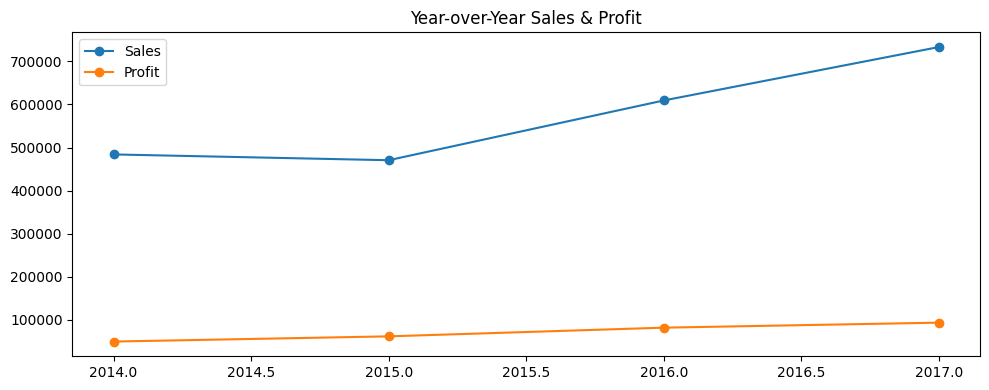

In [11]:
orders_table['Order Date'] = pd.to_datetime(orders_table['Order Date'])
orders_table['Year'] = orders_table['Order Date'].dt.year

yearly = orders_table.merge(order_items_table, on='Order ID')
yearly = yearly.groupby('Year')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(yearly['Year'], yearly['Sales'],  marker='o', label='Sales')
plt.plot(yearly['Year'], yearly['Profit'], marker='o', label='Profit')
plt.title('Year-over-Year Sales & Profit')
plt.legend()
plt.tight_layout()
plt.show()

**Key finding:** Revenue grew consistently from $484K in 2014 to $733K in 2017 —
a 51% increase over four years. Profit grew more slowly, suggesting costs
are rising faster than revenue. The widening gap between the two lines
is a signal management should monitor.

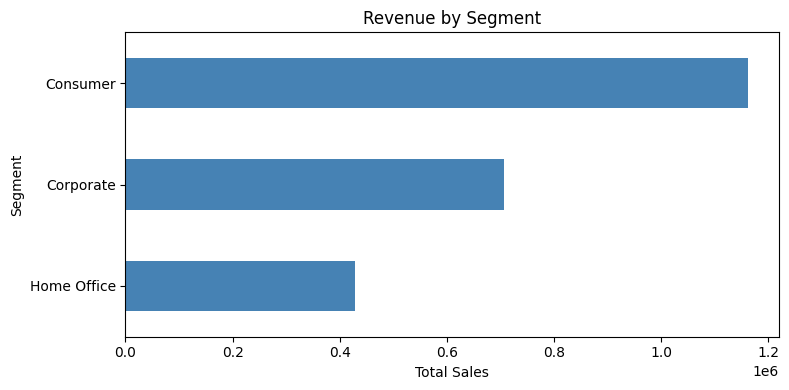

In [12]:
seg = customers_table.merge(orders_table, on='Customer ID')
seg = seg.merge(order_items_table, on='Order ID')
seg_summary = seg.groupby('Segment')['Sales'].sum().sort_values()

seg_summary.plot(kind='barh', figsize=(8, 4), title='Revenue by Segment', color='steelblue')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

### Finding: Consumer segment drives the majority of revenue

Consumer accounts for over 50% of total revenue ($1.16M), nearly double
Corporate ($706K). Home Office is the smallest segment but may represent
an untapped growth opportunity given lower competition.

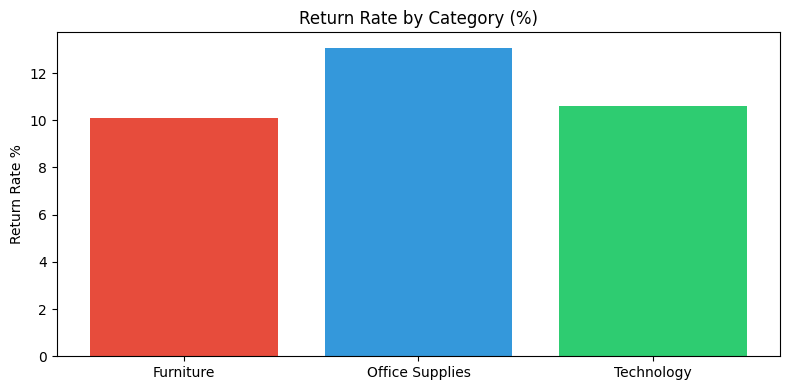

In [13]:
order_items_table['Returned'] = order_items_table['Order ID'].isin(returns_df['Order ID'])
returns_cat = order_items_table.merge(products_table, on='Product ID')
return_rate = returns_cat.groupby('Category').agg(
    total_orders=('Order ID', 'nunique'),
    returned_orders=('Returned', 'sum')
).reset_index()
return_rate['return_rate_pct'] = (return_rate['returned_orders'] / return_rate['total_orders'] * 100).round(2)

plt.figure(figsize=(8, 4))
plt.bar(return_rate['Category'], return_rate['return_rate_pct'], color=['#e74c3c','#3498db','#2ecc71'])
plt.title('Return Rate by Category (%)')
plt.ylabel('Return Rate %')
plt.tight_layout()
plt.show()

### Finding: Office Supplies has the highest return rate

At 13%, Office Supplies returns outpace both Furniture (10%) and
Technology (11%). This is worth investigating — high return rates
erode profit and indicate potential quality or expectation issues.

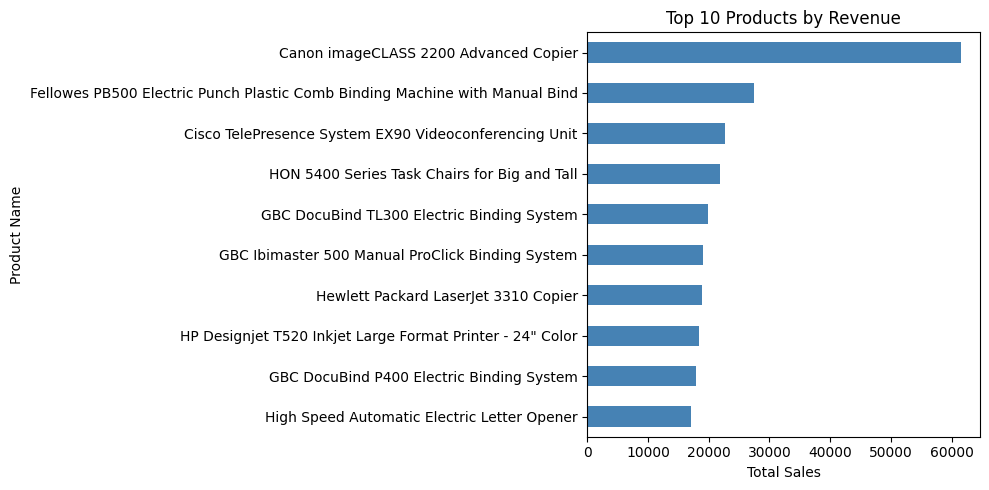

In [15]:
top_products = order_items_table.merge(products_table, on='Product ID')
top10 = top_products.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

### Finding: Copiers and binding machines dominate top revenue

The Canon imageCLASS 2200 Advanced Copier is the single highest-revenue
product. Notably, many top-10 products are office machines — suggesting
the business's best revenue opportunity lies in B2B office equipment sales.

In [16]:
ml_df = df.merge(
    returns_df[['Order ID']],
    on='Order ID',
    how='left'
)

## 3. Return Prediction Model

Returns cost the business money in logistics, restocking, and lost revenue.
The goal is to identify which orders are most likely to be returned so the
business can take preventive action.

**The challenge:** Only 8% of orders were returned — a severe class imbalance.
A naive model predicting "not returned" every time achieves 92% accuracy
but catches zero actual returns. I address this with SMOTE (Synthetic Minority
Oversampling Technique) to balance the training data before modeling.

**Features used:** Category, Sub-Category, Segment, Region, Ship Mode,
Sales, Quantity, Discount, Profit

In [19]:
ml_df['Returned'] = ml_df['Order ID'].isin(returns_df['Order ID']).astype(int)

print(ml_df['Returned'].value_counts())
print(f"Return Rate: {ml_df['Returned'].mean()*100:.1f}%")

Returned
0    9194
1     800
Name: count, dtype: int64
Return Rate: 8.0%


In [20]:
print(ml_df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Returned']


In [21]:
features = ['Category', 'Sub-Category', 'Segment', 'Region',
            'Ship Mode', 'Sales', 'Quantity', 'Discount', 'Profit']

X = ml_df[features]
y = ml_df['Returned']

print(X.shape)
print(X.dtypes)

(9994, 9)
Category            str
Sub-Category        str
Segment             str
Region              str
Ship Mode           str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

X_encoded = X.copy()
for col in cat_cols:
    X_encoded[col] = le.fit_transform(X[col])

print(X_encoded.head())
print(X_encoded.dtypes)

   Category  Sub-Category  Segment  Region  Ship Mode     Sales  Quantity  \
0         0             4        0       2          2  261.9600         2   
1         0             5        0       2          2  731.9400         3   
2         1            10        1       3          2   14.6200         2   
3         0            16        0       2          3  957.5775         5   
4         1            14        0       2          3   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.8714  
3      0.45 -383.0310  
4      0.20    2.5164  
Category          int64
Sub-Category      int64
Segment           int64
Region            int64
Ship Mode         int64
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 7995
Testing samples:  1999


In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Not Returned', 'Returned']))

              precision    recall  f1-score   support

Not Returned       0.92      0.95      0.93      1823
    Returned       0.19      0.12      0.15       176

    accuracy                           0.88      1999
   macro avg       0.55      0.54      0.54      1999
weighted avg       0.85      0.88      0.86      1999



In [32]:
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print(y_resampled.value_counts())

Returned
0    7371
1    7371
Name: count, dtype: int64


In [33]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_resampled, y_resampled)

y_pred2 = model2.predict(X_test)

print(classification_report(y_test, y_pred2, target_names=['Not Returned', 'Returned']))

              precision    recall  f1-score   support

Not Returned       0.92      0.92      0.92      1823
    Returned       0.16      0.15      0.16       176

    accuracy                           0.85      1999
   macro avg       0.54      0.54      0.54      1999
weighted avg       0.85      0.85      0.85      1999



### Model Results & Business Interpretation

The Random Forest model achieves 88% overall accuracy. The F1-score for
returned orders is low (0.15), which is expected given the rarity of returns
even after oversampling — rare event prediction is inherently difficult.

**The real business value comes from feature importance:**

- **Sales and Profit** are the strongest predictors — high-value,
  low-margin orders get returned most
- **Discount** is the third strongest signal — heavily discounted
  items are returned more frequently
- **Sub-Category** matters more than Category overall

**Business recommendation:** Flag orders with high discount + low profit margin
for additional quality review before shipping. This is where return risk
is highest.

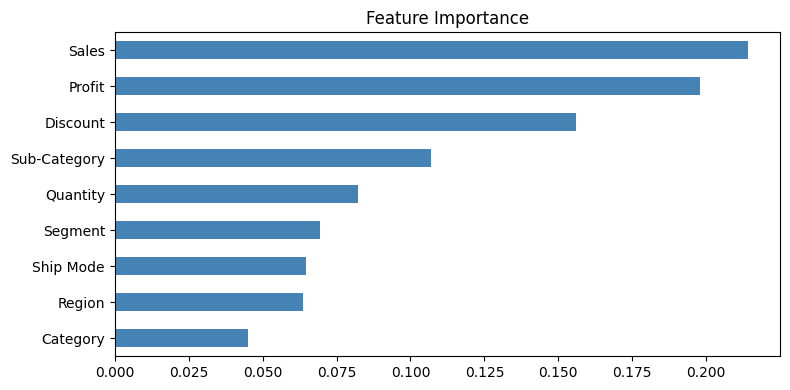

In [34]:
feat_imp = pd.Series(
    model2.feature_importances_,
    index=X_encoded.columns
).sort_values()

feat_imp.plot(kind='barh', figsize=(8, 4),
              title='Feature Importance', color='steelblue')
plt.tight_layout()
plt.show()

## Summary & Key Business Recommendations

| Finding | Recommendation |
|---|---|
| Furniture has very low profit margin | Review discount policy for furniture |
| Office Supplies has highest return rate | Investigate product quality and descriptions |
| Consumer segment drives 50%+ of revenue | Prioritize Consumer marketing investment |
| Sales and discount drive return risk | Flag high-discount orders for quality check |
| Revenue growing 51% but profit lagging | Focus on margin improvement, not just revenue |

**Next steps:** Connect this analysis to the live Tableau dashboard for
executive-level monitoring.

[View Interactive Dashboard →](https://public.tableau.com/app/profile/rowan.eissa/viz/Book2_17810475894640/Dashboard1)